# FL Algorithm Comparison — Averaged Last 50 Rounds
Compares FedAvg, FedProx, FedDC, SCAFFOLD across IID / Non-IID for both datasets,  
with Centralized as upper-bound benchmark.  
Metrics: Accuracy, Macro F1, Loss, Fit Wall Time, Comm (MB), Memory (MB)

## ── Cell 1 · Configuration ──────────────────────────────────────────────────

In [1]:
import os
import glob
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from IPython.display import display
warnings.filterwarnings('ignore')

# ── Paths ──────────────────────────────────────────────────────────────────
RESULTS_DIR = "/home/clara/Research2.0/fyp_fl_smart_home/results"
LAST_N      = 50
ARCH        = "lstm"

ALGOS    = ["fedavg", "fedprox", "feddc", "scaffold"]
DATASETS = ["casas", "uci"]

CENTRALIZED_FILES = {
    "casas" : f"casas_{ARCH}_centralized_benchmark.csv",
    "uci"   : f"uci_{ARCH}_centralized_benchmark.csv",
}

ALGO_COLORS = {
    "centralized" : "#2d3a8c",
    "fedavg"      : "#e53e3e",
    "fedprox"     : "#d97706",
    "feddc"       : "#805ad5",
    "scaffold"    : "#38a169",
}
DATASET_DISPLAY = {"casas": "CASAS Aruba", "uci": "UCI-HAR"}
ALGO_DISPLAY    = {
    "centralized" : "Centralized",
    "fedavg"      : "FedAvg",
    "fedprox"     : "FedProx",
    "feddc"       : "FedDC",
    "scaffold"    : "SCAFFOLD",
}
print(f"Config loaded | arch={ARCH.upper()} | last_N={LAST_N}")

# ── File naming convention ─────────────────────────────────────────────────
# Expected pattern:
#   {dataset}_{arch}_{algo}_{partition}_r{rounds}_nodp.csv          (no-DP)
#   {dataset}_{arch}_{algo}_{partition}_r{rounds}_nodp.csv          (centralized)
# Adjust PATTERN_* below if your filenames differ.

# ── Algorithms ─────────────────────────────────────────────────────────────
ALGOS = ["fedavg", "fedprox", "feddc", "scaffold"]

# ── Partitions ─────────────────────────────────────────────────────────────
PARTITIONS = {
    "iid"     : "iid",
    "non_iid" : "non_iid_a0_1",   # adjust alpha suffix if different
}

# ── Datasets ────────────────────────────────────────────────────────────────
DATASETS = ["casas", "uci"]

# ── Centralized result files (one per dataset) ─────────────────────────────
# Set to None if you don't have centralized results yet
CENTRALIZED_FILES = {
    "casas" : f"casas_{ARCH}_centralized_r150_nodp.csv",   # ← update filename
    "uci"   : f"uci_{ARCH}_centralized_r150_nodp.csv",     # ← update filename
}

# ── Visual styles ───────────────────────────────────────────────────────────
ALGO_COLORS = {
    "centralized" : "#2d3a8c",
    "fedavg"      : "#e53e3e",
    "fedprox"     : "#d97706",
    "feddc"       : "#805ad5",
    "scaffold"    : "#38a169",
}
DATASET_DISPLAY = {"casas": "CASAS Aruba", "uci": "UCI-HAR"}
ALGO_DISPLAY    = {
    "centralized" : "Centralized",
    "fedavg"      : "FedAvg",
    "fedprox"     : "FedProx",
    "feddc"       : "FedDC",
    "scaffold"    : "SCAFFOLD",
}

print(f"Config loaded | arch={ARCH.upper()} | last_N={LAST_N} | results_dir={RESULTS_DIR}")

Config loaded | arch=LSTM | last_N=50
Config loaded | arch=LSTM | last_N=50 | results_dir=/home/clara/Research2.0/fyp_fl_smart_home/results


## ── Cell 2 · File Finder & Loader ───────────────────────────────────────────

In [2]:
import os, glob
import pandas as pd
import numpy as np

def find_file(dataset, arch, algo, partition_key):
    """
    Handles two naming conventions:
      FedProx → {dataset}_{arch}_fedprox_{iid|non_iid}_a0.1_r500_nodp.csv
                 or {dataset}_{arch}_fedprox_iid_r500_fl.csv
      Others  → {dataset}_{arch}_{algo}_{iid|non_iid}_r500_fl.csv
    """
    part = "iid" if partition_key == "iid" else "non_iid"

    candidates = [
        # FedProx nodp pattern (with alpha)
        f"{dataset}_{arch}_{algo}_{part}_a0.1_r500_nodp.csv",
        # Standard fl pattern
        f"{dataset}_{arch}_{algo}_{part}_r500_fl.csv",
        # FedProx without alpha
        f"{dataset}_{arch}_{algo}_{part}_r500_nodp.csv",
    ]
    for name in candidates:
        full = os.path.join(RESULTS_DIR, name)
        if os.path.exists(full):
            return full

    # Fallback glob
    for pattern in [f"{dataset}_{arch}_{algo}_{part}*nodp*.csv",
                    f"{dataset}_{arch}_{algo}_{part}*fl*.csv"]:
        hits = glob.glob(os.path.join(RESULTS_DIR, pattern))
        if hits:
            return sorted(hits)[0]
    return None


def find_centralized(dataset):
    fname = CENTRALIZED_FILES.get(dataset)
    if fname:
        full = os.path.join(RESULTS_DIR, fname)
        if os.path.exists(full):
            return full
    hits = glob.glob(os.path.join(RESULTS_DIR, f"{dataset}_{ARCH}_central*.csv"))
    return sorted(hits)[0] if hits else None


def get_col(df, *names):
    for n in names:
        if n in df.columns:
            return n
    return None


def compute_metrics(path, last_n=LAST_N):
    if path is None or not os.path.exists(path):
        return None
    df   = pd.read_csv(path)
    tail = df.iloc[-last_n:]
    c_acc  = get_col(tail, "accuracy")
    c_f1   = get_col(tail, "f1", "f1_score", "macro_f1")
    c_loss = get_col(tail, "loss")
    c_time = get_col(tail, "fit_wall_s", "wall_time_s", "time_s")
    c_comm = get_col(tail, "comm_bytes_down", "comm_bytes", "comm_down")
    c_mem  = get_col(tail, "memory_usage_mb", "memory_mb", "mem_mb")
    return {
        "Acc (%)"   : round(tail[c_acc].mean()  * 100, 2) if c_acc  else None,
        "F1 (%)"    : round(tail[c_f1].mean()   * 100, 2) if c_f1   else None,
        "Loss"      : round(tail[c_loss].mean(),        2) if c_loss else None,
        "Time (s)"  : round(tail[c_time].mean(),        2) if c_time else None,
        "Comm (MB)" : round(tail[c_comm].mean() / 1e6,  4) if c_comm else None,
        "Mem (MB)"  : round(tail[c_mem].mean(),          1) if c_mem  else None,
    }

print("Helper functions ready.")

Helper functions ready.


## ── Cell 3 · Build Results Table ────────────────────────────────────────────

In [3]:
records  = []
missing  = []

# ── Centralized (benchmark) ─────────────────────────────────────────────────
for ds in DATASETS:
    path    = find_centralized(ds)
    metrics = compute_metrics(path)
    if metrics:
        records.append({"Dataset": ds, "Algorithm": "centralized",
                        "Partition": "—", **metrics})
    else:
        missing.append(f"{ds.upper()} / Centralized")

# ── FL algorithms (IID + Non-IID) ──────────────────────────────────────────
for ds in DATASETS:
    for algo in ALGOS:
        for part_key in ["iid", "non_iid"]:
            path    = find_file(ds, ARCH, algo, part_key)
            metrics = compute_metrics(path)
            label   = "IID" if part_key == "iid" else "Non-IID"
            if metrics:
                records.append({"Dataset": ds, "Algorithm": algo,
                                "Partition": label, **metrics})
            else:
                missing.append(f"{ds.upper()} / {algo.upper()} / {label}")

raw_df = pd.DataFrame(records)

if raw_df.empty:
    print("[!] No data loaded. Check RESULTS_DIR and file names above.")
else:
    print(f"Loaded {len(records)} result(s).")
    display(raw_df.head(10))

if missing:
    print(f"[!] {len(missing)} file(s) not found:")
    for m in missing:
        print(f"     {m}")
    print()

print(f"Loaded {len(records)} result(s).")
raw_df.head(10)


Loaded 18 result(s).


,Dataset,Algorithm,Partition,Acc (%),F1 (%),Loss,Time (s),Comm (MB),Mem (MB)
0,casas,centralized,—,96.34,86.94,0.10,3.03,NaN,NaN
1,uci,centralized,—,93.73,93.68,0.39,0.83,NaN,NaN
2,casas,fedavg,IID,91.22,68.06,0.26,NaN,NaN,NaN
3,casas,fedavg,Non-IID,66.30,38.32,2.80,NaN,NaN,NaN
4,casas,fedprox,IID,97.69,91.28,0.06,10.69,0.8039,1192.2
5,casas,fedprox,Non-IID,93.19,79.38,0.22,6.42,0.8039,1361.3
6,casas,feddc,IID,96.26,85.10,0.11,NaN,NaN,NaN
7,casas,feddc,Non-IID,92.80,76.02,0.21,NaN,NaN,NaN
8,casas,scaffold,IID,96.20,85.67,0.12,NaN,NaN,NaN
9,casas,scaffold,Non-IID,93.30,78.05,0.20,NaN,NaN,NaN


Loaded 18 result(s).


,Dataset,Algorithm,Partition,Acc (%),F1 (%),Loss,Time (s),Comm (MB),Mem (MB)
0,casas,centralized,—,96.34,86.94,0.10,3.03,NaN,NaN
1,uci,centralized,—,93.73,93.68,0.39,0.83,NaN,NaN
2,casas,fedavg,IID,91.22,68.06,0.26,NaN,NaN,NaN
3,casas,fedavg,Non-IID,66.30,38.32,2.80,NaN,NaN,NaN
4,casas,fedprox,IID,97.69,91.28,0.06,10.69,0.8039,1192.2
5,casas,fedprox,Non-IID,93.19,79.38,0.22,6.42,0.8039,1361.3
6,casas,feddc,IID,96.26,85.10,0.11,NaN,NaN,NaN
7,casas,feddc,Non-IID,92.80,76.02,0.21,NaN,NaN,NaN
8,casas,scaffold,IID,96.20,85.67,0.12,NaN,NaN,NaN
9,casas,scaffold,Non-IID,93.30,78.05,0.20,NaN,NaN,NaN


## ── Cell 4 · Styled Summary Table ───────────────────────────────────────────

In [4]:
def build_display_table(dataset):
    """
    Returns a styled DataFrame for one dataset.
    Centralized row first, then FL algorithms grouped IID / Non-IID.
    """
    sub = raw_df[raw_df["Dataset"] == dataset].copy()

    # ordered index
    order = [("centralized", "—")]
    for algo in ALGOS:
        order += [(algo, "IID"), (algo, "Non-IID")]

    rows = []
    for algo, part in order:
        match = sub[(sub["Algorithm"] == algo) & (sub["Partition"] == part)]
        if match.empty:
            continue
        r = match.iloc[0]
        algo_lbl = ALGO_DISPLAY.get(algo, algo.upper())
        row = {
            "Method"      : algo_lbl,
            "Partition"   : part,
            "Acc (%)"     : f"{r['Acc (%)']:.2f}"  if r["Acc (%)"]   is not None else "—",
            "F1 (%)"      : f"{r['F1 (%)']:.2f}"   if r["F1 (%)"]    is not None else "—",
            "Loss"        : f"{r['Loss']:.2f}"      if r["Loss"]      is not None else "—",
            "Time (s)"    : f"{r['Time (s)']:.2f}"  if r["Time (s)"]  is not None else "—",
            "Comm (MB)"   : f"{r['Comm (MB)']:.4f}" if r["Comm (MB)"] is not None else "—",
            "Mem (MB)"    : f"{r['Mem (MB)']:.1f}"  if r["Mem (MB)"]  is not None else "—",
        }
        rows.append(row)

    tbl = pd.DataFrame(rows).set_index(["Method", "Partition"])
    return tbl


def highlight_best(df):
    """Highlight best Acc and F1 per column (excluding centralized row)."""
    styled = df.style.set_caption("").set_table_styles([
        {"selector": "th", "props": [("background-color", "#2d3a8c"),
                                      ("color", "white"),
                                      ("font-weight", "bold"),
                                      ("text-align", "center")]},
        {"selector": "td", "props": [("text-align", "center"),
                                      ("padding", "6px 12px")]},
        {"selector": "tr:nth-child(1)",
         "props": [("background-color", "#e8eaf6"), ("font-weight", "bold")]},  # centralized
    ])
    return styled


for ds in DATASETS:
    tbl = build_display_table(ds)
    if tbl.empty:
        print(f"[!] No data for {DATASET_DISPLAY[ds]}")
        continue
    print(f"\n{'═'*70}")
    print(f"  Dataset: {DATASET_DISPLAY[ds]}  |  Arch: {ARCH.upper()}  |  Last {LAST_N} rounds avg")
    print(f"{'═'*70}")
    display(highlight_best(tbl))


══════════════════════════════════════════════════════════════════════
  Dataset: CASAS Aruba  |  Arch: LSTM  |  Last 50 rounds avg
══════════════════════════════════════════════════════════════════════



══════════════════════════════════════════════════════════════════════
  Dataset: UCI-HAR  |  Arch: LSTM  |  Last 50 rounds avg
══════════════════════════════════════════════════════════════════════


## ── Cell 5 · Bar Chart — Accuracy & F1 Comparison ───────────────────────────

Saved → fl_algo_comparison_acc_f1_lstm.png


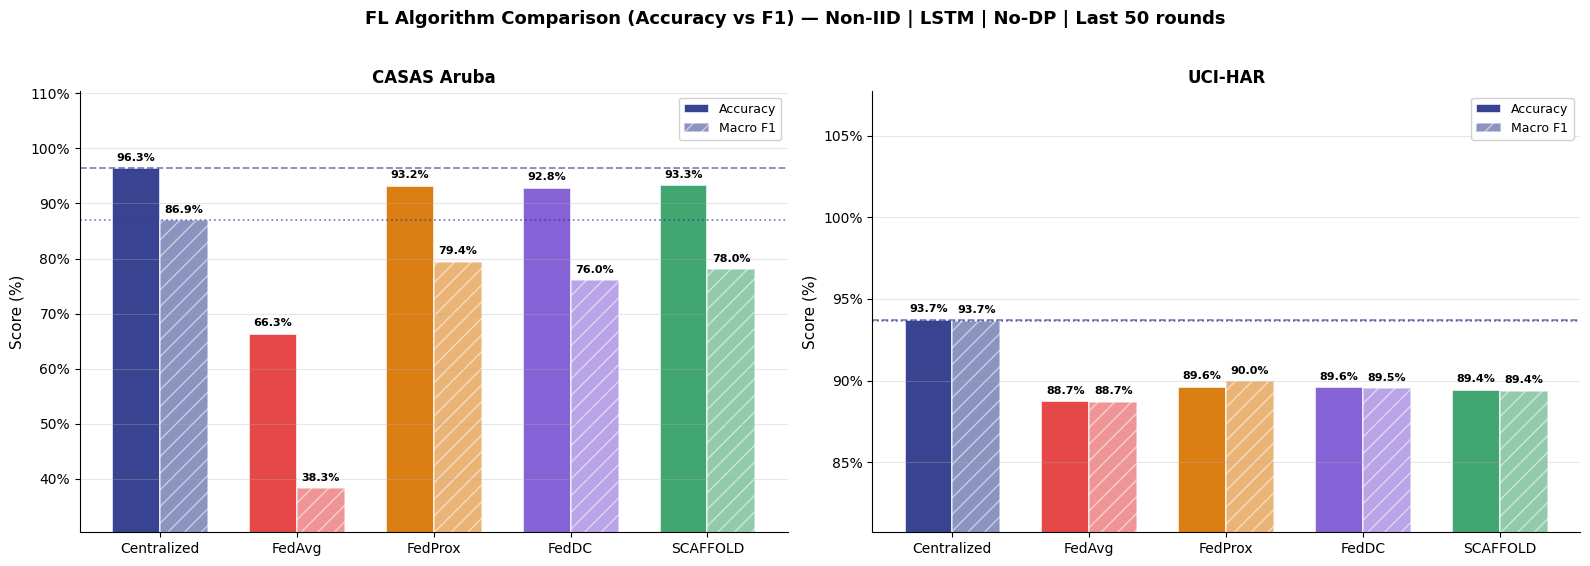

In [5]:
def plot_acc_f1_grouped(dataset, ax=None):
    sub    = raw_df[raw_df["Dataset"] == dataset].copy()

    labels, acc_vals, f1_vals, colors = [], [], [], []

    # centralized
    cent = sub[sub["Algorithm"] == "centralized"]
    if not cent.empty:
        labels.append("Centralized")
        acc_vals.append(float(cent.iloc[0]["Acc (%)"]))
        f1_vals.append(float(cent.iloc[0]["F1 (%)"]))
        colors.append(ALGO_COLORS["centralized"])

    # Non-IID only
    for algo in ALGOS:
        row = sub[(sub["Algorithm"] == algo) & (sub["Partition"] == "Non-IID")]
        if row.empty:
            continue
        labels.append(ALGO_DISPLAY[algo])
        acc_vals.append(float(row.iloc[0]["Acc (%)"]))
        f1_vals.append(float(row.iloc[0]["F1 (%)"]))
        colors.append(ALGO_COLORS[algo])

    if ax is None:
        fig, ax = plt.subplots(figsize=(9, 5))

    x     = np.arange(len(labels))
    width = 0.35

    bars_acc = ax.bar(x - width/2, acc_vals, width, color=colors,
                      edgecolor="white", linewidth=1.2, alpha=0.95, label="Accuracy")
    bars_f1  = ax.bar(x + width/2, f1_vals,  width, color=colors,
                      edgecolor="white", linewidth=1.2, alpha=0.55, label="Macro F1",
                      hatch="//")

    # value annotations
    for bar, val in zip(bars_acc, acc_vals):
        ax.annotate(f"{val:.1f}%",
                    xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                    xytext=(0, 4), textcoords="offset points",
                    ha="center", va="bottom", fontsize=8, fontweight="bold")
    for bar, val in zip(bars_f1, f1_vals):
        ax.annotate(f"{val:.1f}%",
                    xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                    xytext=(0, 4), textcoords="offset points",
                    ha="center", va="bottom", fontsize=8, fontweight="bold")

    # centralized dashed lines
    if not cent.empty:
        ax.axhline(acc_vals[0], color=ALGO_COLORS["centralized"],
                   ls="--", lw=1.3, alpha=0.6)
        ax.axhline(f1_vals[0],  color=ALGO_COLORS["centralized"],
                   ls=":",  lw=1.3, alpha=0.6)

    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=10)
    ax.set_ylabel("Score (%)", fontsize=11)
    ax.set_title(f"{DATASET_DISPLAY[dataset]}", fontsize=12, fontweight="bold")
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.0f%%'))
    all_vals = acc_vals + f1_vals
    ax.set_ylim(max(0, min(all_vals) - 8), max(all_vals) + 14)
    ax.legend(fontsize=9, framealpha=0.9)
    ax.grid(axis="y", alpha=0.3)
    ax.spines[["top", "right"]].set_visible(False)


# ── Side-by-side: CASAS | UCI ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))
for ax, ds in zip(axes, DATASETS):
    plot_acc_f1_grouped(ds, ax=ax)

fig.suptitle(
    f"FL Algorithm Comparison (Accuracy vs F1) — Non-IID | {ARCH.upper()} | No-DP | Last {LAST_N} rounds",
    fontsize=13, fontweight="bold", y=1.02
)
plt.tight_layout()
out = f"fl_algo_comparison_acc_f1_{ARCH}.png"
plt.savefig(out, bbox_inches="tight", dpi=150)
print(f"Saved → {out}")
plt.show()

## ── Cell 7 · Export to CSV ───────────────────────────────────────────────────

In [6]:
out_csv = f"fl_algo_comparison_{ARCH}_last{LAST_N}.csv"
raw_df["Algorithm"] = raw_df["Algorithm"].map(lambda x: ALGO_DISPLAY.get(x, x.upper()))
raw_df["Dataset"]   = raw_df["Dataset"].map(lambda x: DATASET_DISPLAY.get(x, x))
raw_df.to_csv(out_csv, index=False)
print(f"Saved → {out_csv}")
raw_df

Saved → fl_algo_comparison_lstm_last50.csv


,Dataset,Algorithm,Partition,Acc (%),F1 (%),Loss,Time (s),Comm (MB),Mem (MB)
0,CASAS Aruba,Centralized,—,96.34,86.94,0.10,3.03,NaN,NaN
1,UCI-HAR,Centralized,—,93.73,93.68,0.39,0.83,NaN,NaN
2,CASAS Aruba,FedAvg,IID,91.22,68.06,0.26,NaN,NaN,NaN
3,CASAS Aruba,FedAvg,Non-IID,66.30,38.32,2.80,NaN,NaN,NaN
4,CASAS Aruba,FedProx,IID,97.69,91.28,0.06,10.69,0.8039,1192.2
5,CASAS Aruba,FedProx,Non-IID,93.19,79.38,0.22,6.42,0.8039,1361.3
6,CASAS Aruba,FedDC,IID,96.26,85.10,0.11,NaN,NaN,NaN
7,CASAS Aruba,FedDC,Non-IID,92.80,76.02,0.21,NaN,NaN,NaN
8,CASAS Aruba,SCAFFOLD,IID,96.20,85.67,0.12,NaN,NaN,NaN
9,CASAS Aruba,SCAFFOLD,Non-IID,93.30,78.05,0.20,NaN,NaN,NaN
